Failed for orb-v3 (orb-v3)

Failed for upet (pet-oam-xl)

Failed for nequix (nequix-mp)

Failed for m3gnet (m3gnet)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
cols = ["model", "index", "element", "energy", "status", "error"]

df = pd.read_csv("results/isolated_atom_energies.csv", header=0, names=cols)

df.columns = df.columns.str.strip()
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["energy"] = pd.to_numeric(df["energy"], errors="coerce")

filtered = df[df["status"] == "ok"]

In [3]:
results = {}
for ei in filtered["element"].unique()[:80]:
    values = filtered[filtered["element"] == ei]["energy"].values
    values = values[values != 0]
    results[ei] = values

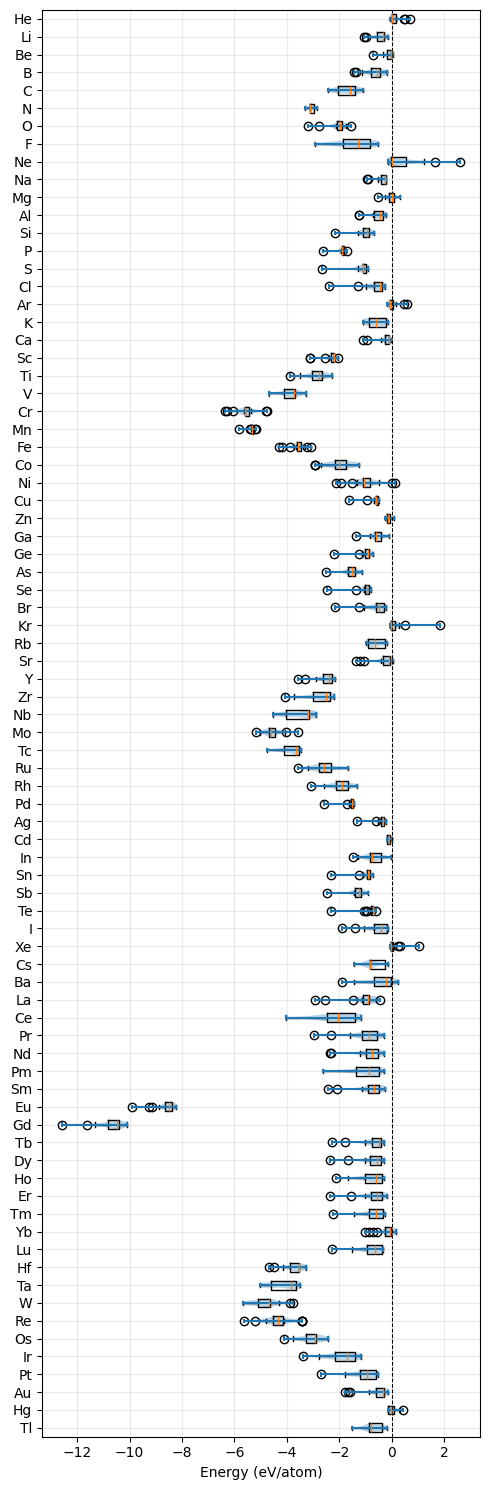

In [5]:
elements = list(results.keys())
data = [results[e] for e in elements]

plt.figure(figsize=(5, 15))

plt.boxplot(data, vert=False)
plt.violinplot(data, vert=False)

plt.axvline(0, color="black", linestyle="--", linewidth=0.75)

plt.xlabel("Energy (eV/atom)")
plt.yticks(range(1, len(elements) + 1), elements, rotation=0)

plt.grid("major", alpha=0.25)

plt.ylim(reversed(plt.ylim()))

plt.tight_layout()
plt.show()

In [15]:
df["model"].unique()

array(['chgnet', 'calculator_name', 'mace-mp', 'hienet', 'grace-1l-oam',
       'eqnorm-mptrj', 'dpa-3.1-3m-ft', 'grace-2l-oam', 'grace-2l-mp-r6',
       'dpa-3.1-mptrj', 'matris-10m-mp', 'matris-10m-oam', 'mace-mpa-0',
       'mace-mp-0', 'nequix-mp-pft', 'allegro-mp-l', 'nequip-oam-l',
       'nequip-mp-l', 'mattersim-v1', 'sevennet-l3i5', 'tace-v1-oam-m',
       'sevennet-omni', 'orb-v2-mptrj', 'orb-v2'], dtype=object)